Project Aim: Create a passing network 
A passing network is a weighted graph. 

In [1]:
from statsbombpy import sb 
from mplsoccer import Pitch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
free_competitions = sb.competitions()
champions_league = free_competitions[free_competitions['competition_name'] == 'Champions League']
champions_league_2011 = sb.matches(competition_id=16, season_id=22) 
champions_league_2011

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,18236,2011-05-28,20:45:00.000,Europe - Champions League,2010/2011,Barcelona,Manchester United,3,1,available,...,2021-06-13T16:17:31.694,1,Final,Wembley Stadium,Viktor Kassai,Josep Guardiola i Sala,Alex Ferguson,1.0.3,None,None


In [3]:
CL_final_2011 = sb.events(match_id=18236)
CL_final_2011.columns

Index(['bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'block_save_block',
       'carry_end_location', 'clearance_aerial_won', 'counterpress',
       'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type',
       'duration', 'foul_committed_advantage', 'foul_committed_card',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'off_camera', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_backheel', 'pass_body_part', 'pass_cross', 'pass_end_location',
       'pass_goal_assist', 'pass_height', 'pass_length', 'pass_outcome',
       'pass_recipient', 'pass_recipient_id', 'pass_shot_assist',
       'pass_switch', 'pass_type', 'period',

In [4]:
CL_final_2011 = CL_final_2011[['team', 'minute', 'type', 'pass_type', 'pass_outcome', 'player', 'pass_recipient', 'location', 'pass_end_location']]
CL_final_2011['type'].unique(), CL_final_2011['pass_type'].unique(), CL_final_2011['pass_outcome'].unique()

(<ArrowStringArray>
 [      'Starting XI',        'Half Start',              'Pass',
      'Ball Receipt*',             'Carry',          'Pressure',
       'Dispossessed',              'Duel',     'Ball Recovery',
      'Dribbled Past',           'Dribble',    'Tactical Shift',
       'Interception',             'Block',              'Shot',
        'Goal Keeper',    'Foul Committed',          'Foul Won',
         'Miscontrol',         'Clearance',            'Shield',
  'Referee Ball-Drop',          'Half End',           'Offside',
       'Substitution',     'Bad Behaviour']
 Length: 26, dtype: str,
 <ArrowStringArray>
 [           nan,     'Kick Off',     'Throw-in', 'Interception',
      'Recovery',    'Free Kick',       'Corner',    'Goal Kick']
 Length: 8, dtype: str,
 <ArrowStringArray>
 [nan, 'Out', 'Incomplete', 'Pass Offside', 'Unknown', 'Injury Clearance']
 Length: 6, dtype: str)

We are only interested in 

In [5]:
# We filter for passes which are not throw-ins and the team is Barcelona
passes = CL_final_2011[(CL_final_2011['type'] == 'Pass') & (CL_final_2011['pass_type'] != 'Throw-in') & (CL_final_2011['team'] == 'Barcelona')]
# We want only succesful passes, we update the empty values to be succesful passes
passes['pass_outcome'] = passes['pass_outcome'].fillna('Succesful')
# We now filter the DataFrame to include only succesful passes
passes = passes[passes['pass_outcome'] == 'Succesful']
passes.head()

,team,minute,type,pass_type,pass_outcome,player,pass_recipient,location,pass_end_location
10,Barcelona,0,Pass,NaN,Succesful,Lionel Andrés Messi Cuccittini,Sergio Busquets i Burgos,"[51.0, 16.0]","[50.0, 25.0]"
11,Barcelona,0,Pass,NaN,Succesful,Sergio Busquets i Burgos,Daniel Alves da Silva,"[53.0, 28.0]","[55.0, 65.0]"
17,Barcelona,0,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,"[8.0, 40.0]","[6.0, 70.0]"
18,Barcelona,1,Pass,NaN,Succesful,Javier Alejandro Mascherano,Víctor Valdés Arribas,"[21.0, 65.0]","[6.0, 48.0]"
19,Barcelona,1,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,"[5.0, 50.0]","[17.0, 78.0]"


In [6]:
# We want to isolate the start and end (x,y) coordinates of each pass 
passes['pas_x'] = passes['location'].str[0]
passes['pas_y'] = passes['location'].str[1]
passes['rec_x'] = passes['pass_end_location'].str[0]
passes['rec_y'] = passes['pass_end_location'].str[1]
# Tidy up the DataFrame
passes.drop(columns=['location', 'pass_end_location'], inplace=True)
passes.head()

,team,minute,type,pass_type,pass_outcome,player,pass_recipient,pas_x,pas_y,rec_x,rec_y
10,Barcelona,0,Pass,NaN,Succesful,Lionel Andrés Messi Cuccittini,Sergio Busquets i Burgos,51.0,16.0,50.0,25.0
11,Barcelona,0,Pass,NaN,Succesful,Sergio Busquets i Burgos,Daniel Alves da Silva,53.0,28.0,55.0,65.0
17,Barcelona,0,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,8.0,40.0,6.0,70.0
18,Barcelona,1,Pass,NaN,Succesful,Javier Alejandro Mascherano,Víctor Valdés Arribas,21.0,65.0,6.0,48.0
19,Barcelona,1,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,5.0,50.0,17.0,78.0


We want to filter the DataFrame so that it only inclues events before the first substitution. 

In [7]:
# Find the minute at which the first substitution occurs
substitues = CL_final_2011[(CL_final_2011['type'] == 'Substitution') & (CL_final_2011['team'] == 'Barcelona')]
first_substitute = substitues['minute'].min()

In [8]:
# Filter the DataFrame to only include passes which occured before the first substitution
passes = passes[passes['minute'] < first_substitute]
passes.head(-5)

,team,minute,type,pass_type,pass_outcome,player,pass_recipient,pas_x,pas_y,rec_x,rec_y
10,Barcelona,0,Pass,NaN,Succesful,Lionel Andrés Messi Cuccittini,Sergio Busquets i Burgos,51.0,16.0,50.0,25.0
11,Barcelona,0,Pass,NaN,Succesful,Sergio Busquets i Burgos,Daniel Alves da Silva,53.0,28.0,55.0,65.0
17,Barcelona,0,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,8.0,40.0,6.0,70.0
18,Barcelona,1,Pass,NaN,Succesful,Javier Alejandro Mascherano,Víctor Valdés Arribas,21.0,65.0,6.0,48.0
19,Barcelona,1,Pass,NaN,Succesful,Víctor Valdés Arribas,Javier Alejandro Mascherano,5.0,50.0,17.0,78.0
...,...,...,...,...,...,...,...,...,...,...,...
1109,Barcelona,83,Pass,NaN,Succesful,Daniel Alves da Silva,Sergio Busquets i Burgos,21.0,74.0,39.0,64.0
1110,Barcelona,83,Pass,NaN,Succesful,Sergio Busquets i Burgos,Javier Alejandro Mascherano,38.0,59.0,21.0,68.0
1111,Barcelona,83,Pass,NaN,Succesful,Javier Alejandro Mascherano,David Villa Sánchez,26.0,72.0,80.0,79.0
1115,Barcelona,83,Pass,NaN,Succesful,Sergio Busquets i Burgos,David Villa Sánchez,57.0,78.0,61.0,76.0


We want to create a new DataFrame for the nodes. The nodes will be the average psosition from which each player made a pass. 

In [18]:
players = passes.groupby('player').agg(pas_x_avg = ('pas_x', 'mean'), pas_y_avg = ('pas_y', 'mean'), total_passes_made = ('pas_x', 'count')).reset_index()
# A little bit of 'data hacking' is required to add player's shirt numbers
players['numbers'] = [8,2,7,22,3,14,10,17,16,1,6]

players

,player,pas_x_avg,pas_y_avg,total_passes_made,numbers
0,Andrés Iniesta Luján,70.456311,30.611650,103,8
1,Daniel Alves da Silva,61.525424,69.915254,59,2
2,David Villa Sánchez,80.583333,57.666667,24,7
3,Eric-Sylvain Bilal Abidal,60.279070,12.139535,43,22
4,Gerard Piqué Bernabéu,41.204545,32.113636,44,3
5,Javier Alejandro Mascherano,40.509804,56.000000,51,14
6,Lionel Andrés Messi Cuccittini,77.336842,45.115789,95,10
7,Pedro Eliezer Rodríguez Ledesma,83.468750,13.031250,32,17
8,Sergio Busquets i Burgos,55.906667,38.306667,75,16
9,Víctor Valdés Arribas,11.500000,41.000000,20,1


In [10]:
passes_between = passes.groupby(['player', 'pass_recipient']).agg( passes_count=('pas_x','count')).reset_index()
passes_between.head(20)

,player,pass_recipient,passes_count
0,Andrés Iniesta Luján,Daniel Alves da Silva,8
1,Andrés Iniesta Luján,David Villa Sánchez,2
2,Andrés Iniesta Luján,Eric-Sylvain Bilal Abidal,6
3,Andrés Iniesta Luján,Gerard Piqué Bernabéu,4
4,Andrés Iniesta Luján,Javier Alejandro Mascherano,3
5,Andrés Iniesta Luján,Lionel Andrés Messi Cuccittini,33
6,Andrés Iniesta Luján,Pedro Eliezer Rodríguez Ledesma,10
7,Andrés Iniesta Luján,Sergio Busquets i Burgos,11
8,Andrés Iniesta Luján,Xavier Hernández Creus,26
9,Daniel Alves da Silva,Andrés Iniesta Luján,4


Next, we want to create a DataFrame for the edges. The edges are the Player who made the pass and the Recipient Player, the size of the edges is the number of passes between these players. 

In [11]:
edges = passes_between.merge(players, how='left', on='player')
edges = edges.rename(columns={'player':'passer', 'pas_x_avg':'pas_x', 'pas_y_avg':'pas_y'})

# We create a copy of the players DataFrame, which we will use to add the pass recipients location to the edges DataFrame
recipient = players.rename(columns={'player':'pass_recipient'})
edges = edges.merge(recipient, how='left', on='pass_recipient')
edges = edges.rename(columns={'pas_x_avg':'rec_x', 'pas_y_avg':'rec_y'})

edges['line_width'] = (((edges['passes_count'] - edges['passes_count'].min())/ (edges['passes_count'].max() - edges['passes_count'].min())) + 0.1) * 10

edges

,passer,pass_recipient,passes_count,pas_x,pas_y,total_passes_made_x,rec_x,rec_y,total_passes_made_y,line_width
0,Andrés Iniesta Luján,Daniel Alves da Silva,8,70.456311,30.611650,103,61.525424,69.915254,59,3.1875
1,Andrés Iniesta Luján,David Villa Sánchez,2,70.456311,30.611650,103,80.583333,57.666667,24,1.3125
2,Andrés Iniesta Luján,Eric-Sylvain Bilal Abidal,6,70.456311,30.611650,103,60.279070,12.139535,43,2.5625
3,Andrés Iniesta Luján,Gerard Piqué Bernabéu,4,70.456311,30.611650,103,41.204545,32.113636,44,1.9375
4,Andrés Iniesta Luján,Javier Alejandro Mascherano,3,70.456311,30.611650,103,40.509804,56.000000,51,1.6250
...,...,...,...,...,...,...,...,...,...,...
85,Xavier Hernández Creus,Javier Alejandro Mascherano,13,68.366906,42.086331,139,40.509804,56.000000,51,4.7500
86,Xavier Hernández Creus,Lionel Andrés Messi Cuccittini,24,68.366906,42.086331,139,77.336842,45.115789,95,8.1875
87,Xavier Hernández Creus,Pedro Eliezer Rodríguez Ledesma,10,68.366906,42.086331,139,83.468750,13.031250,32,3.8125
88,Xavier Hernández Creus,Sergio Busquets i Burgos,13,68.366906,42.086331,139,55.906667,38.306667,75,4.7500


As an aside, we also want to create a measure of centrality. 

To do so, we take the player who received the most passes(P_max). In this case Xavi with 131. We then calculate the difference between this player and each player (P_i) and sum over these values. 
We divide this value by the number of players - 1 (-1 because the difference between P_max and P_max will always be 0). This denominator is then multiplied by sum of the passes received by P_i. See below formula: 

$$ C = \frac{\sum_{i=1}^{N} (P_* - P_i)}{    (N-1)\sum_{i=1}^{N} P_i} $$

Note: A centrality of 0 means perfectly decentralised, while a centrality of 1 means a single player receives all pases.

In [12]:
passes_received = passes.groupby('pass_recipient').agg(passes_received = ('pas_x', 'count'))
p_max = passes_received['passes_received'].max()

# For each player, we calculate the difference between the p_max and pi (passes received by that plyaer) for each player. 
passes_received['difference'] = p_max - passes_received['passes_received'] 
numerator = passes_received['difference'].sum()
denominator = passes_received['passes_received'].sum() * (len(players) - 1)

centrality = np.round((numerator / denominator) , 2)

passes_received, p_max, numerator, denominator, centrality

(                                 passes_received  difference
 pass_recipient                                              
 Andrés Iniesta Luján                         113          18
 Daniel Alves da Silva                         66          65
 David Villa Sánchez                           33          98
 Eric-Sylvain Bilal Abidal                     43          88
 Gerard Piqué Bernabéu                         33          98
 Javier Alejandro Mascherano                   44          87
 Lionel Andrés Messi Cuccittini               108          23
 Pedro Eliezer Rodríguez Ledesma               37          94
 Sergio Busquets i Burgos                      65          66
 Víctor Valdés Arribas                         12         119
 Xavier Hernández Creus                       131           0,
 131,
 756,
 6850,
 0.11)

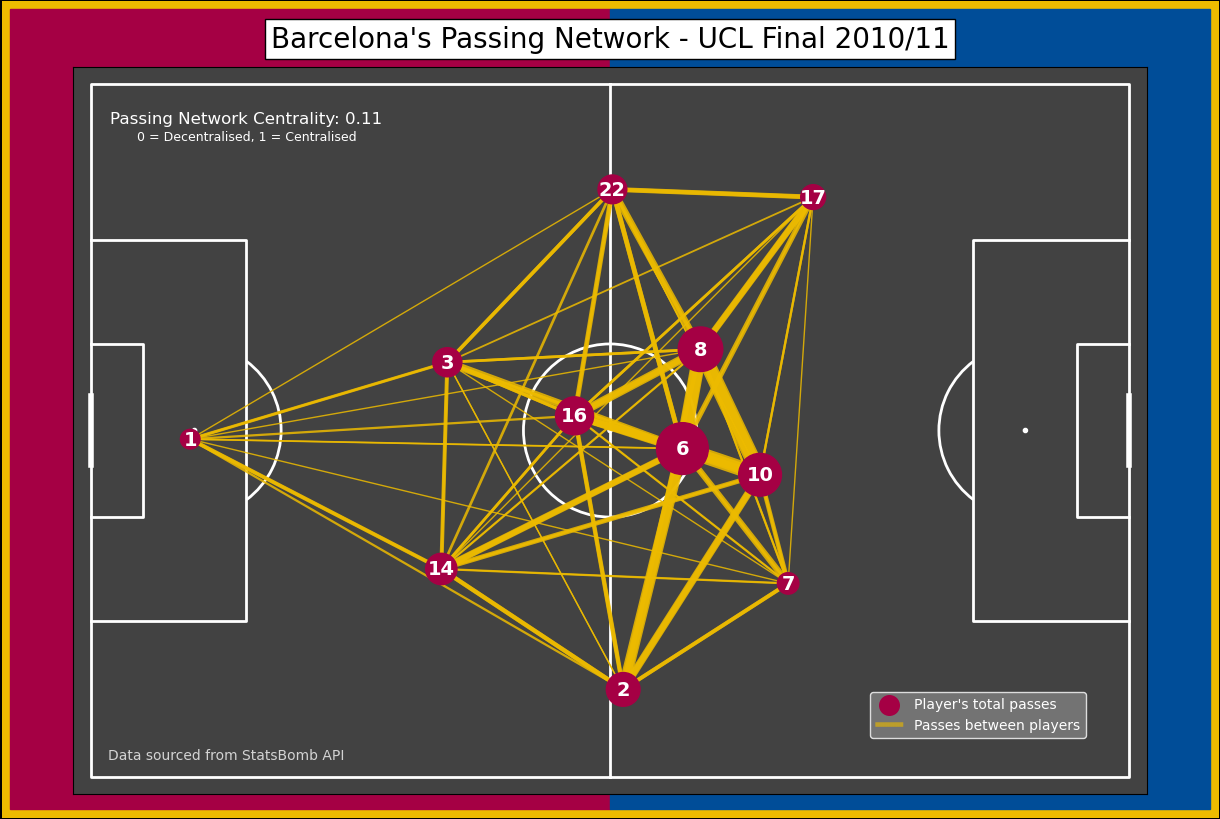

<Figure size 640x480 with 0 Axes>

In [ ]:
pitch = Pitch(pitch_color='#424242', line_color='white', pad_left=2, pad_right=2, pad_top=2, pad_bottom=2, axis=True)
fig, ax = pitch.draw(figsize=(12,8))
# Create the plot
pitch.scatter(players.pas_x_avg, players.pas_y_avg, s=players.total_passes_made*10, ax=ax, color='#a50044', zorder=2, label="Player's total passes")

for row in players.iterrows():
  x = row[1]['pas_x_avg']
  y = row[1]['pas_y_avg']
  shirt_number = row[1]['numbers']
  ax.text(x,y,shirt_number, ha='center', va='center', color='white', fontweight='bold', fontsize=14)


pitch.lines(edges.pas_x, edges.pas_y, edges.rec_x, edges.rec_y, color= '#edbb00', lw=edges.line_width, alpha =0.85, ax=ax, zorder=1, label='Passes between players')
# Add centrality measure
ax.text(18, 4, f"Passing Network Centrality: {centrality}", ha='center', va='center', fontsize = 12, color='white')  
ax.text(18, 6, "0 = Decentralised, 1 = Centralised",ha='center', va='center', fontsize = 9, color='white')  
# Create Barcleona themed background 
fig.set_facecolor('#edbb00')
fig.set_edgecolor('black')
fig.set_linewidth(1)
left_rectangle = patches.Rectangle((0,0),height=1,width=0.5,color='#a50044', zorder=0)
right_rectangle = patches.Rectangle((0.5, 0), height=1, width=0.5, color='#004d98', zorder=0)
fig.add_artist(left_rectangle)
fig.add_artist(right_rectangle)
fig.suptitle(t="Barcelona's Passing Network - UCL Final 2010/11", color='black', ma='center',  fontsize=20, bbox={'facecolor':'white', 'edgecolor': 'black'})
ax.text(x=2, y=78, s="Data sourced from StatsBomb API", color='lightgrey')
plt.legend(loc=1,bbox_to_anchor=(0.95, 0.15), fontsize=10, markerscale=0.5, facecolor='grey', edgecolor='white', labelcolor='white')
plt.savefig('passing_network_UCL_final_2011.png')
plt.show()
plt.clf()